In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
df_clean = pd.read_csv(r"../data/processed/clean_sales.csv")
df_clean.head()

C:\Users\HP\AppData\Local\Temp\ipykernel_22684\3952159728.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df_clean = pd.read_csv(r"../data/processed/clean_sales.csv")


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Id,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-17,4852,519,1,1,0,0,303445,c,a,1270.0,9.0,2008.0,0,0.0,0.0,No Promo
1,2,5,2015-07-17,4518,495,1,1,0,1,959585,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-17,6679,673,1,1,0,1,739744,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-17,10514,1343,1,1,0,1,864001,c,c,620.0,9.0,2009.0,0,0.0,0.0,No Promo
4,5,5,2015-07-17,4355,513,1,1,0,1,981931,a,a,29910.0,4.0,2015.0,0,0.0,0.0,No Promo


In [50]:
df_clean["Date"] = pd.to_datetime(df_clean["Date"])
df_clean["StateHoliday"] = df_clean["StateHoliday"].astype(str)

In [51]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 830918 entries, 0 to 830917
Data columns (total 19 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   Store                      830918 non-null  int64         
 1   DayOfWeek                  830918 non-null  int64         
 2   Date                       830918 non-null  datetime64[ns]
 3   Sales                      830918 non-null  int64         
 4   Customers                  830918 non-null  int64         
 5   Open                       830918 non-null  int64         
 6   Promo                      830918 non-null  int64         
 7   StateHoliday               830918 non-null  object        
 8   SchoolHoliday              830918 non-null  int64         
 9   Id                         830918 non-null  int64         
 10  StoreType                  830918 non-null  object        
 11  Assortment                 830918 non-null  object  

## Univariate Analysis

In [52]:
df_clean.shape

(830918, 19)

In [53]:
df_clean.describe().T

,count,mean,min,25%,50%,75%,max,std
Store,830918.0,558.427284,1.0,280.0,558.0,837.0,1115.0,321.729794
DayOfWeek,830918.0,3.520409,1.0,2.0,3.0,5.0,7.0,1.72376
Date,830918,2014-04-03 11:03:01.196218624,2013-01-01 00:00:00,2013-08-13 00:00:00,2014-03-24 00:00:00,2014-11-28 00:00:00,2015-07-17 00:00:00,NaN
Sales,830918.0,6955.921264,46.0,4858.0,6368.0,8360.0,41551.0,3105.780763
Customers,830918.0,763.391371,8.0,519.0,676.0,893.0,7388.0,401.581886
Open,830918.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0
Promo,830918.0,0.446867,0.0,0.0,0.0,1.0,1.0,0.497169
SchoolHoliday,830918.0,0.187145,0.0,0.0,0.0,0.0,1.0,0.390028
Id,830918.0,508617.930935,0.0,254643.0,509006.5,762723.5,1017205.0,293409.579415
CompetitionDistance,830918.0,5450.515502,20.0,710.0,2330.0,6880.0,75860.0,7801.87819


In [54]:
df_clean.describe(include="object").T

,count,unique,top,freq
StateHoliday,830918,4,0,830008
StoreType,830918,4,a,449818
Assortment,830918,3,a,437767
PromoInterval,830918,4,No Promo,416730


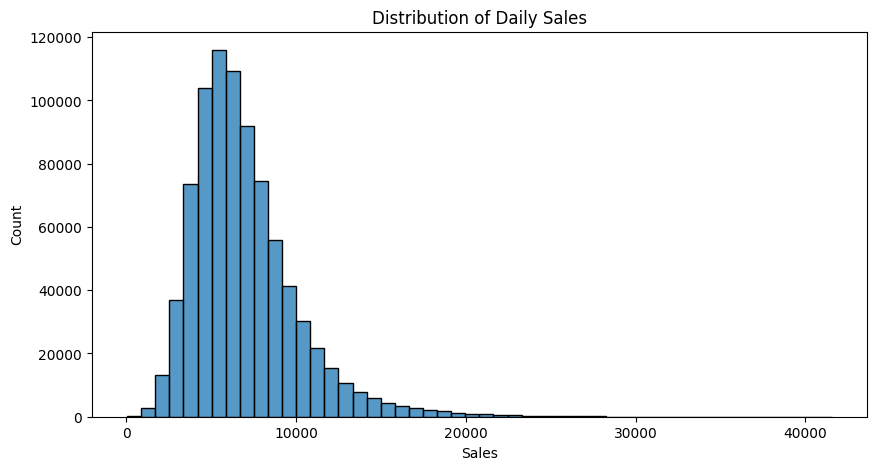

In [55]:
plt.figure(figsize=(10,5))
sns.histplot(df_clean["Sales"], bins=50)

plt.title("Distribution of Daily Sales")
plt.show()

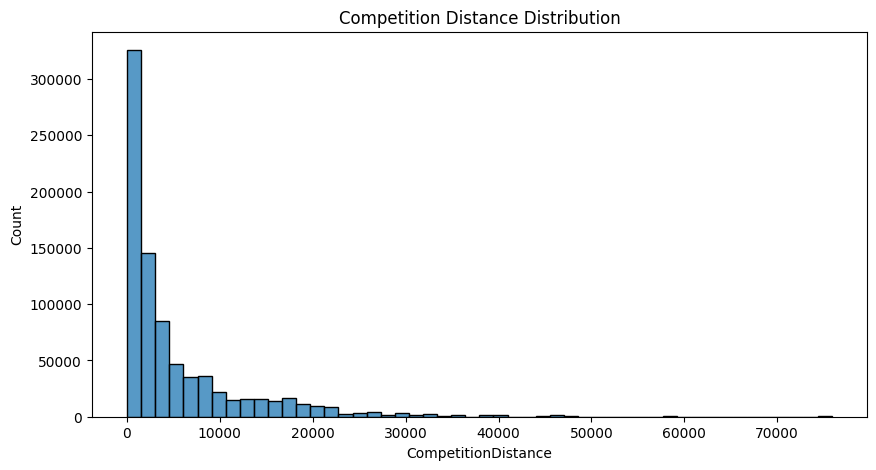

In [56]:
plt.figure(figsize=(10,5))
sns.histplot(df_clean["CompetitionDistance"], bins=50)

plt.title("Competition Distance Distribution")
plt.show()

## Sales Analysis

In [57]:
df_clean["Sales"].describe()

count    830918.000000
mean       6955.921264
std        3105.780763
min          46.000000
25%        4858.000000
50%        6368.000000
75%        8360.000000
max       41551.000000
Name: Sales, dtype: float64

In [58]:
top_store = (
    df_clean.groupby("Store")["Sales"].sum().sort_values(ascending=False).head(10)
)

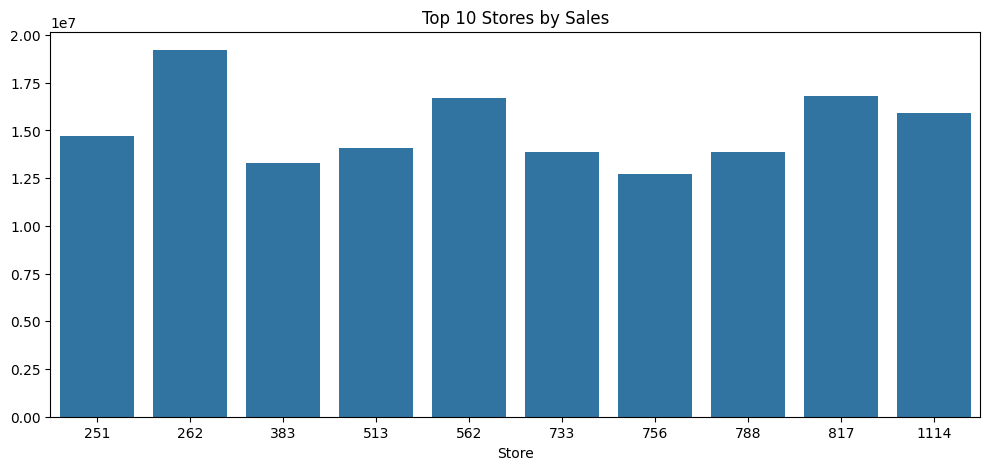

In [59]:

plt.figure(figsize=(12,5))
sns.barplot(x=top_store.index, y=top_store.values)

plt.title("Top 10 Stores by Sales")
plt.show()

## Time Series Analysis

In [60]:
daily_sales = (
    df_clean.groupby("Date")["Sales"].sum()
)

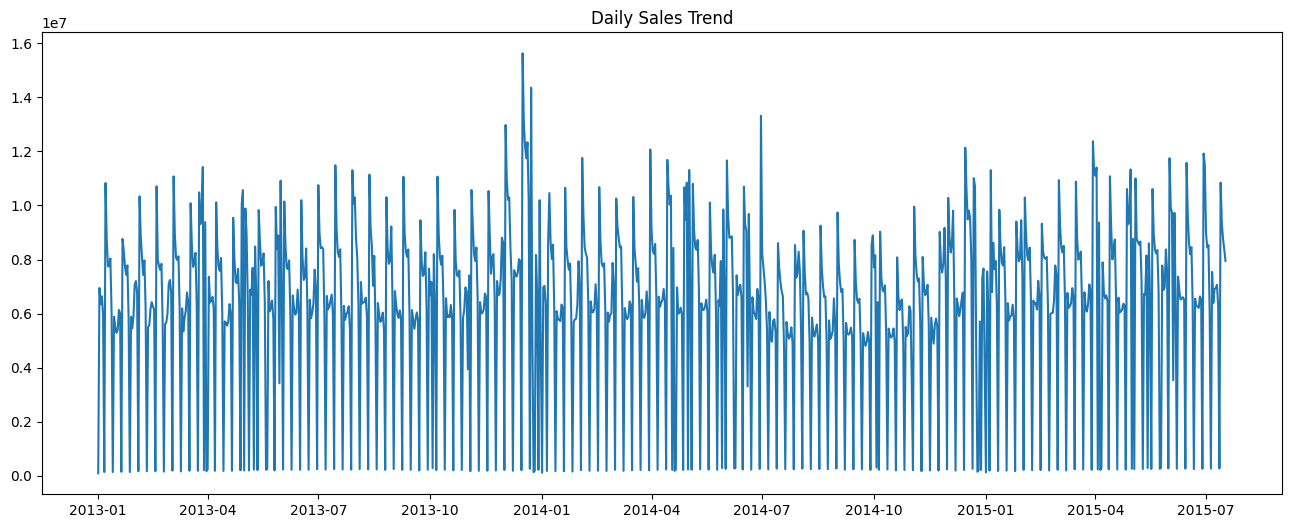

In [61]:
plt.figure(figsize=(16,6))
plt.plot(daily_sales)

plt.title("Daily Sales Trend")
plt.show()

In [69]:
monthly_sales = (
    df_clean.groupby(df_clean["Date"].dt.month)["Sales"].sum()
)
month = {1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May", 6: "Jun", 7: "Jul", 8: "Aug", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"}
monthly_sales = monthly_sales.rename(month)
monthly_sales

Date
Jan    566728724
Feb    528734410
Mar    599831906
Apr    575895295
May    569248217
Jun    578112775
Jul    501678767
Aug    361791202
Sep    342570131
Oct    351878728
Nov    369498877
Dec    433831153
Name: Sales, dtype: int64

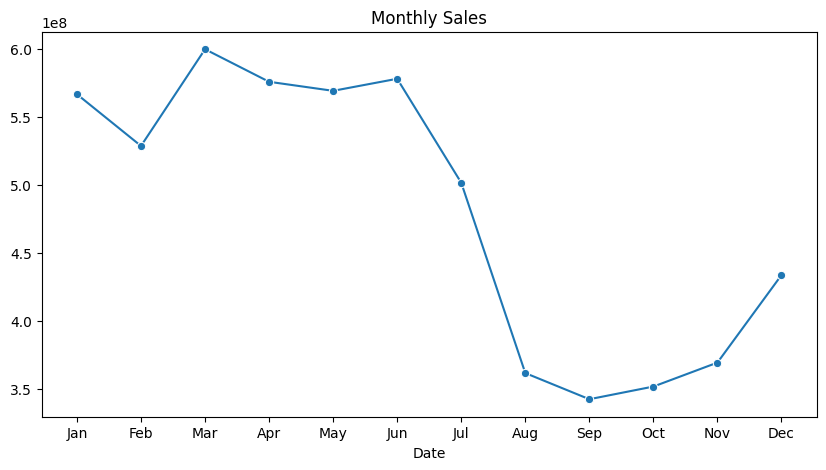

In [70]:

plt.figure(figsize=(10,5))
sns.lineplot(
    x=monthly_sales.index,
    y=monthly_sales.values,
    marker="o"
)

plt.title("Monthly Sales")
plt.show()

In [71]:
yearly_sales = (
    df_clean
    .groupby(df_clean["Date"].dt.year)["Sales"]
    .sum()
)

yearly_sales

Date
2013    2302876084
2014    2180804896
2015    1296119205
Name: Sales, dtype: int64

## Promotion Analysis

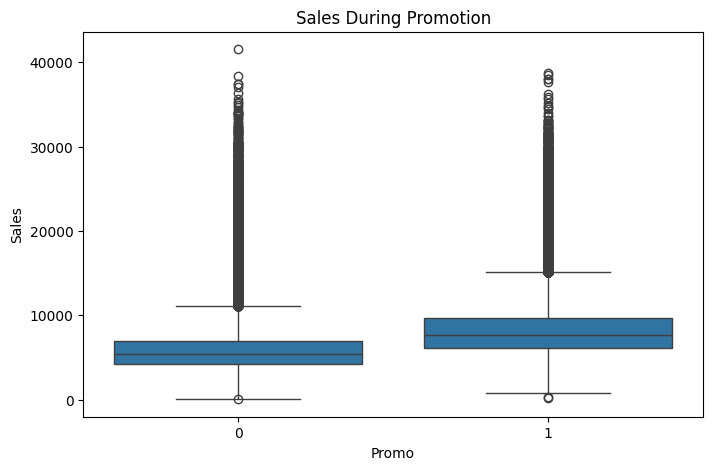

In [72]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Promo", y="Sales", data=df_clean)

plt.title("Sales During Promotion")
plt.show()

In [74]:
df_clean.groupby("Promo")["Sales"].mean()

Promo
0    5930.760174
1    8224.866993
Name: Sales, dtype: float64

## Holiday Analysis

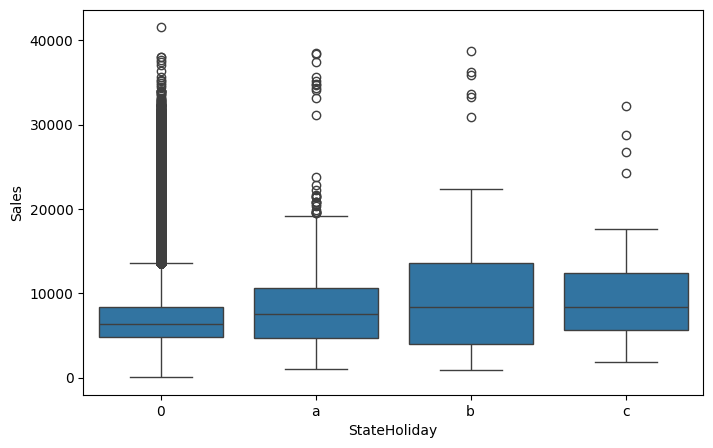

In [75]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x="StateHoliday",
    y="Sales",
    data=df_clean
)

plt.show()

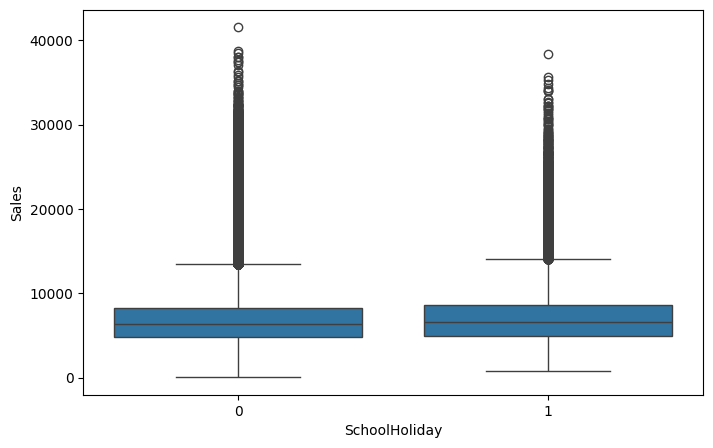

In [76]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x="SchoolHoliday",
    y="Sales",
    data=df_clean
)

plt.show()

## Store Analysis

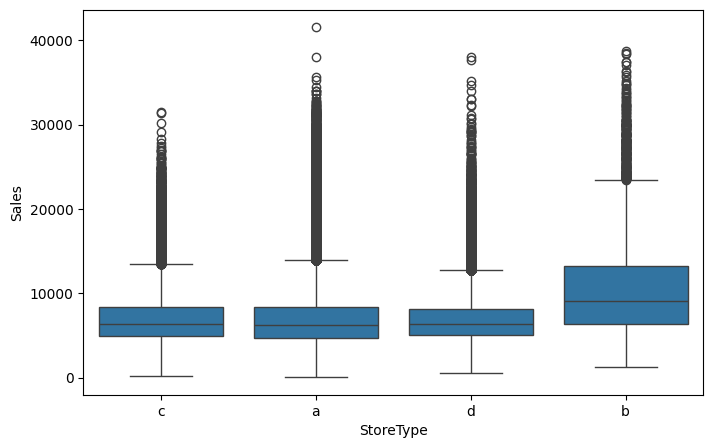

In [77]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x="StoreType",
    y="Sales",
    data=df_clean
)

plt.show()

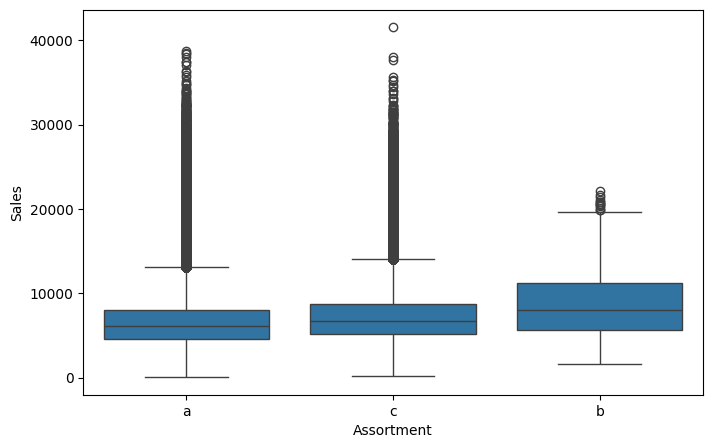

In [78]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x="Assortment",
    y="Sales",
    data=df_clean
)

plt.show()

## Competition Analysis

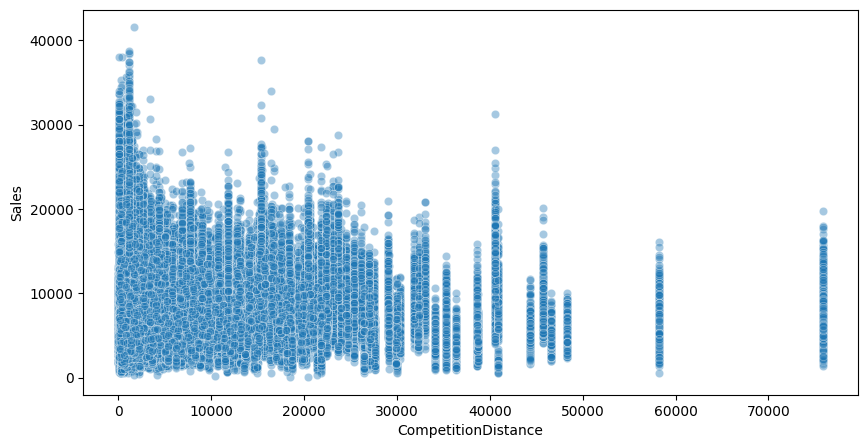

In [79]:
plt.figure(figsize=(10,5))
sns.scatterplot(
    x="CompetitionDistance",
    y="Sales",
    data=df_clean,
    alpha=0.4
)

plt.show()

## Correlation Analysis

In [81]:
numeric_df = df_clean.select_dtypes(include=["number"])
numeric_df.head()

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday,Id,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
0,1,5,4852,519,1,1,0,303445,1270.0,9.0,2008.0,0,0.0,0.0
1,2,5,4518,495,1,1,1,959585,570.0,11.0,2007.0,1,13.0,2010.0
2,3,5,6679,673,1,1,1,739744,14130.0,12.0,2006.0,1,14.0,2011.0
3,4,5,10514,1343,1,1,1,864001,620.0,9.0,2009.0,0,0.0,0.0
4,5,5,4355,513,1,1,1,981931,29910.0,4.0,2015.0,0,0.0,0.0


In [82]:
corr = numeric_df.corr()

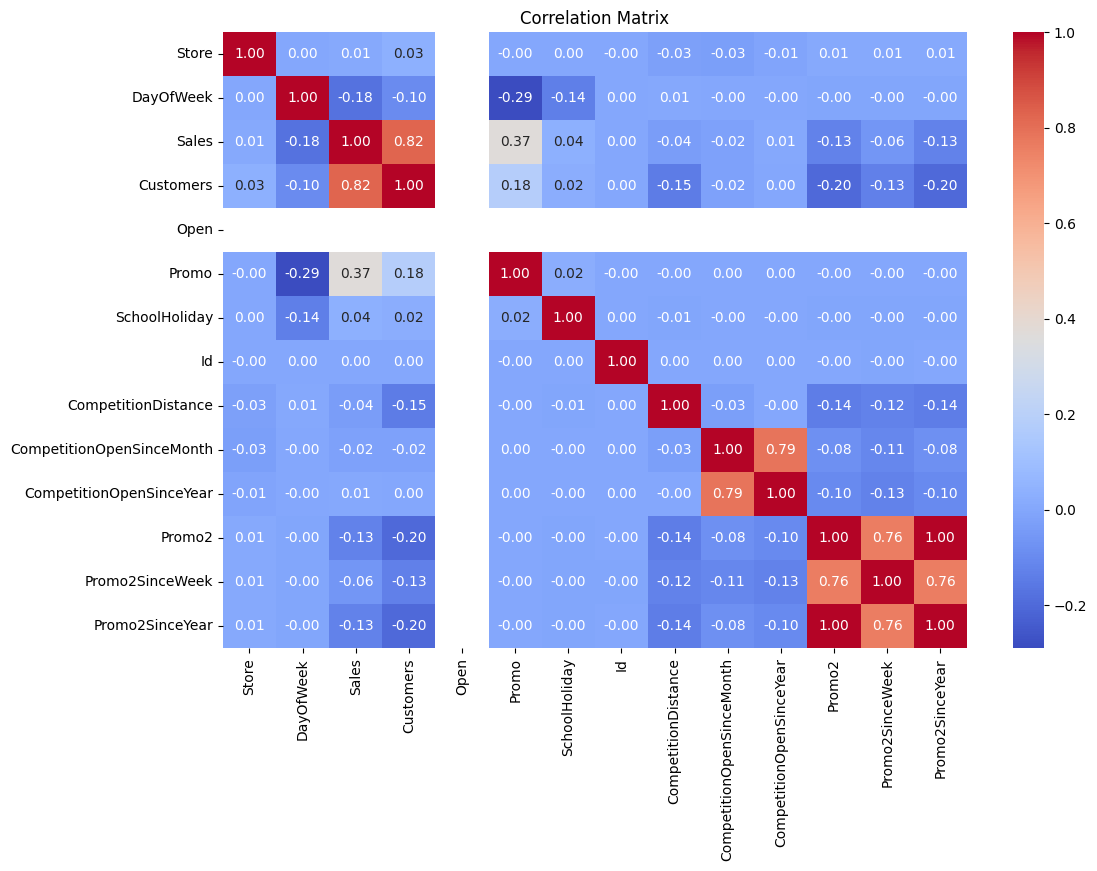

In [83]:
plt.figure(figsize=(12,8))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

## Business Insights

### Key Findings from Exploratory Data Analysis

#### 1. **Promotions Significantly Boost Sales**
- **With Promotion**: 8,224.87 average daily sales
- **Without Promotion**: 5,930.76 average daily sales
- **Impact**: Promotions increase sales by **~39%** on average
- **Recommendation**: Increase frequency of promotional campaigns during low-sales periods

#### 2. **Strong Seasonality Pattern**
- **Peak Months**: January (566.7M) and March (599.8M)
- **Lowest Months**: August (361.8M), September (342.6M), and October (351.9M)
- **Summer Slump**: Clear decline during summer months (July-October)
- **Recommendation**: Plan additional marketing and promotions during August-September to combat seasonal dip

#### 3. **Declining Sales Trend Over Years**
- **2013**: 2.30B (Peak)
- **2014**: 2.18B (-5.3%)
- **2015**: 1.30B (-40.4%)
- **Concern**: Significant decline in 2015 indicates market challenges or data collection period
- **Recommendation**: Investigate root causes of 2015 decline

#### 4. **Sales Distribution Insights**
- **Average Daily Sales**: 6,955.92
- **Median Daily Sales**: 6,368.00
- **Range**: 46 - 41,551 (high variability)
- **Consistency**: Most stores cluster around 4,858-8,360 (IQR), indicating relatively stable performance

#### 5. **Store Performance Concentration**
- **Top 10 Stores** generate significantly higher revenue than others
- **Insights**: Market concentration with a few high-performing stores
- **Recommendation**: Replicate successful strategies from top stores to underperforming locations

#### 6. **Holiday Effects**
- State holidays and school holidays show varying impacts on sales
- **Recommendation**: Analyze specific holiday periods to optimize staffing and inventory

#### 7. **Store Type & Assortment**
- Performance varies by store type and assortment level
- **Recommendation**: Focus on high-performing store formats for expansion

#### 8. **Competition Distance**
- Competition proximity may influence store sales
- **Recommendation**: Monitor competitive landscape and adjust pricing/promotions accordingly
